In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scienceplots

## import data

In [53]:
# panel
panel_df = pd.read_csv('../data/processed/panel_df.csv', dtype={'nace_code': str, 'nacenace_2dig': str})
panel_df = panel_df.replace("n.d.", np.nan)

C:\Users\nicol\AppData\Local\Temp\ipykernel_11548\2308067940.py:2: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  panel_df = pd.read_csv('../data/processed/panel_df.csv', dtype={'nace_code': str, 'nacenace_2dig': str})


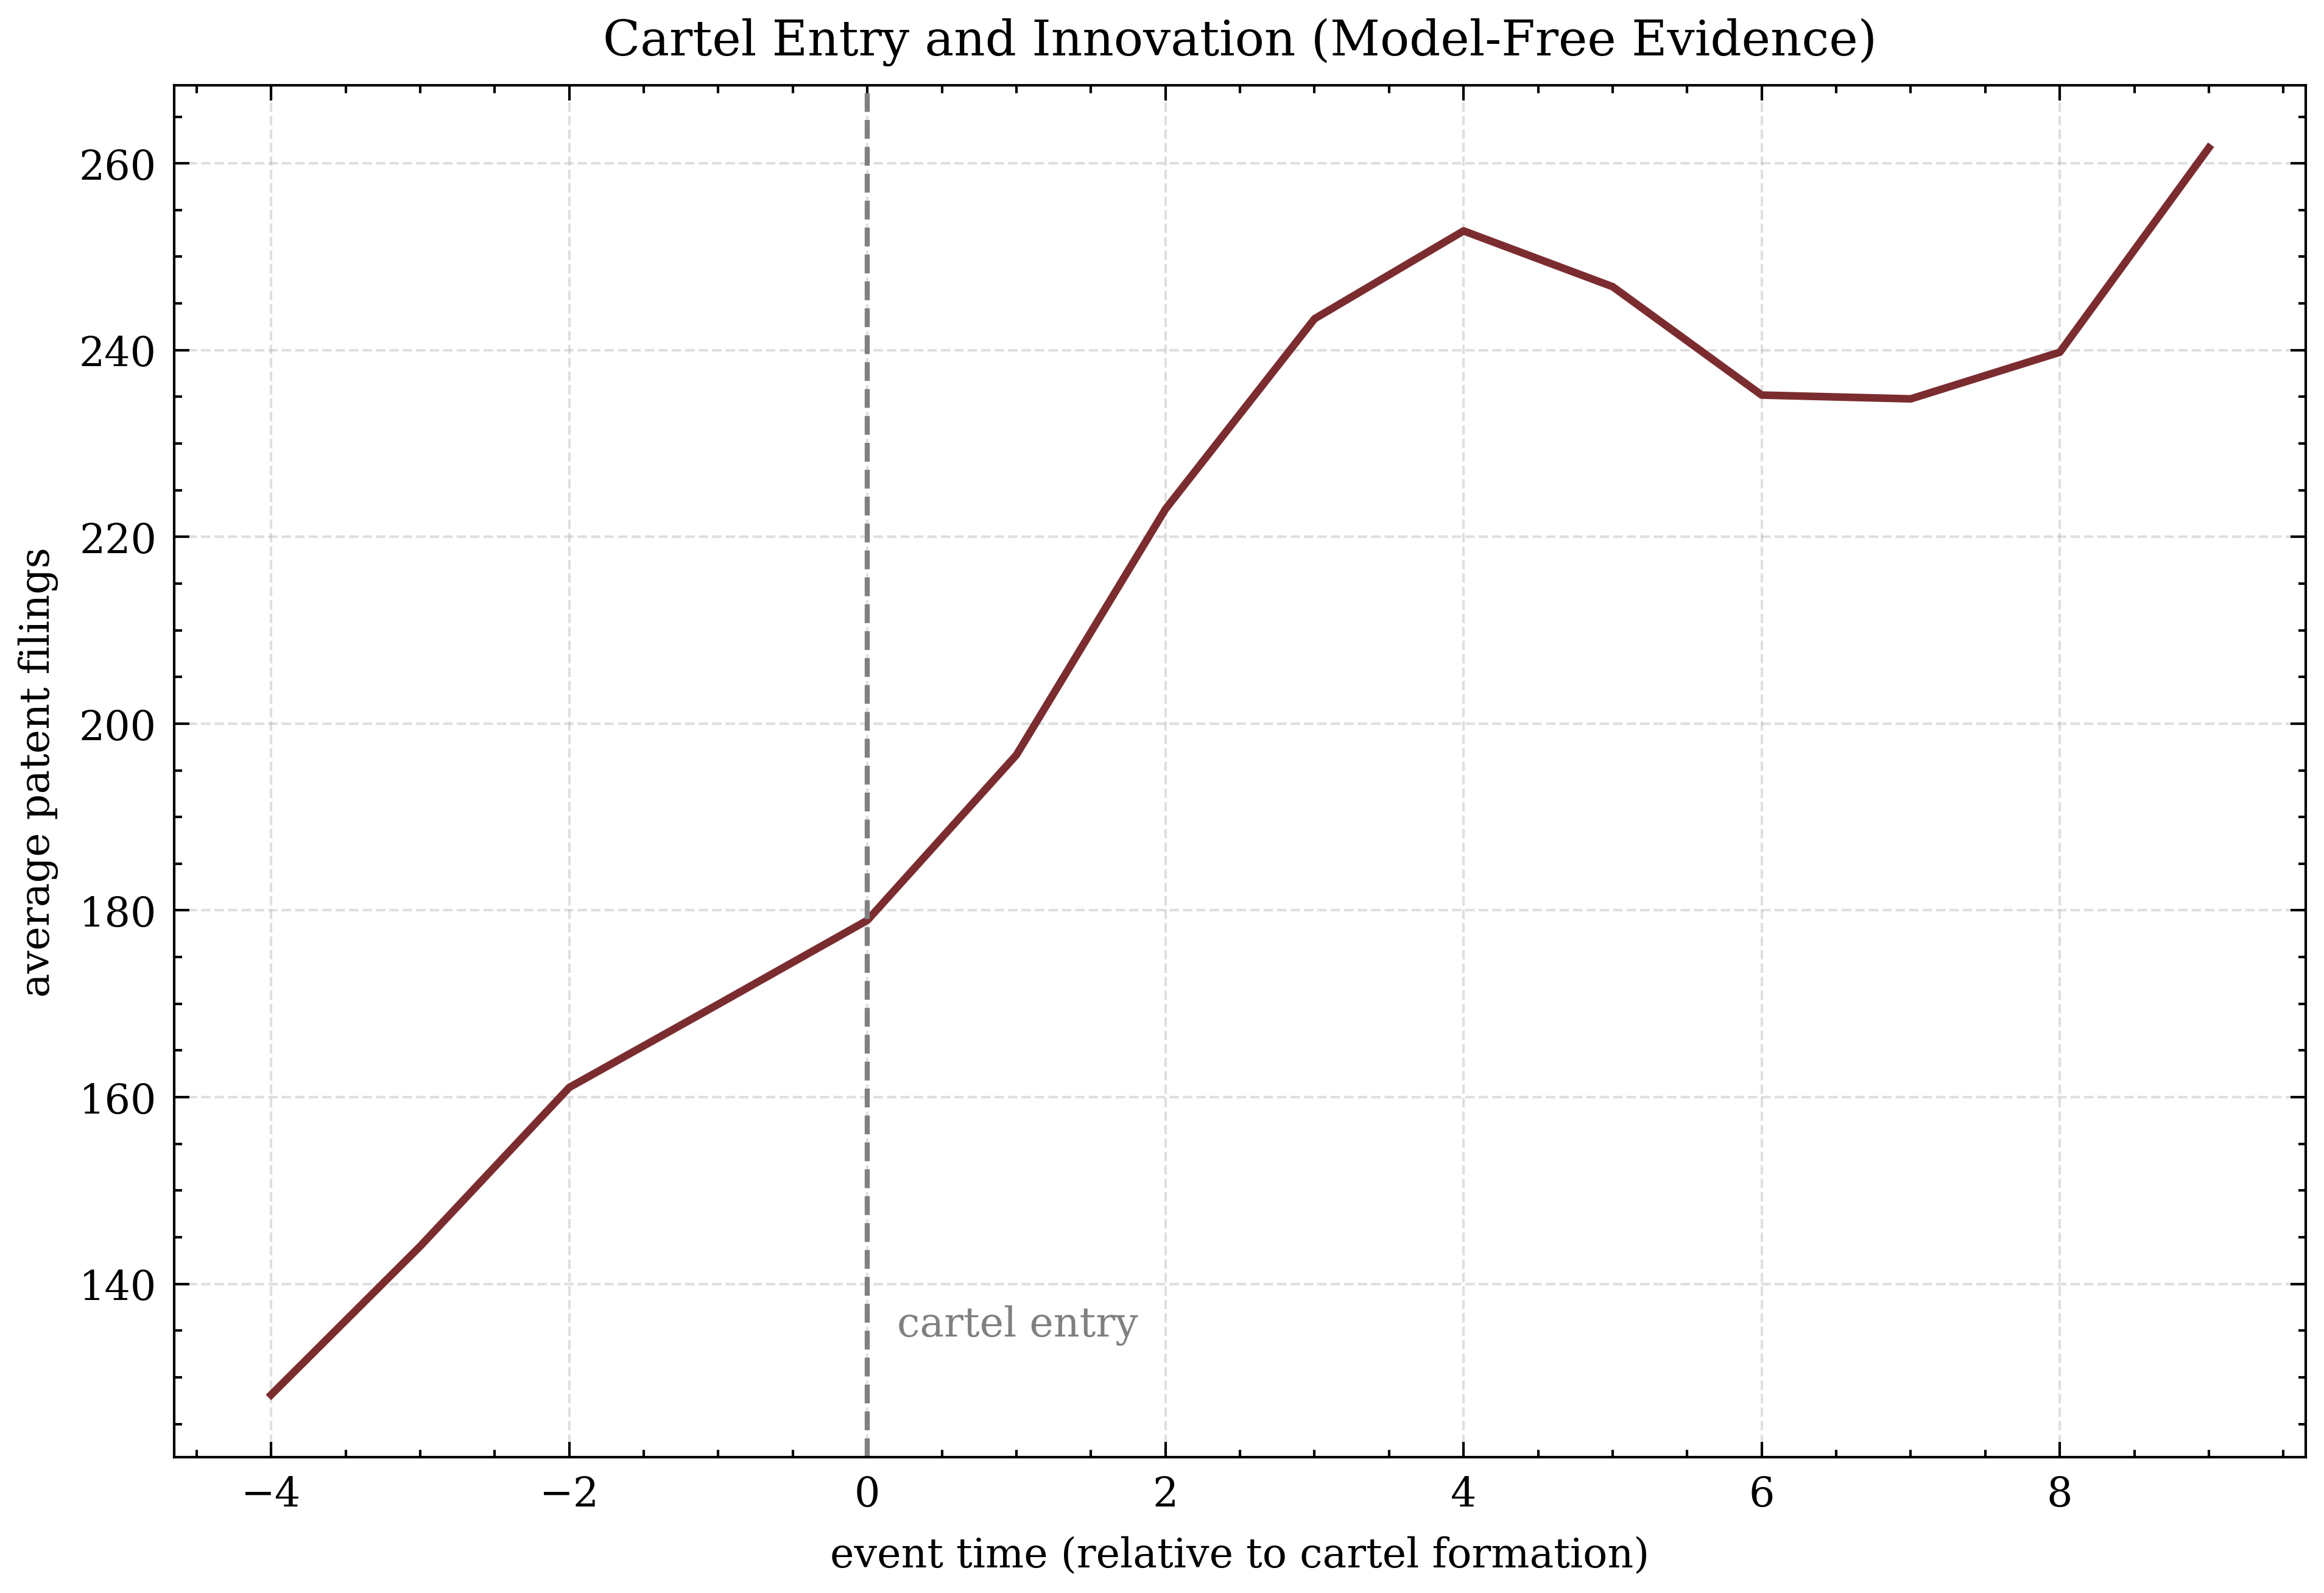

In [140]:
df_event = panel_df[(panel_df['event_time_entry'] >= -5) & (panel_df['event_time_entry'] <= 10)]

df_event_summary = (
    df_event.groupby('event_time_entry')['filed_pat']
    .agg(['mean', 'count', 'std'])
    .reset_index()
)
df_event_summary['smooth_mean'] = df_event_summary['mean'].rolling(window=3, center=True).mean()

plt.style.use(['science', 'ieee'])

# Fix font warnings
plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'DejaVu Serif'
plt.rcParams['mathtext.fontset'] = 'dejavuserif'

# Plot as before
fig, ax = plt.subplots(figsize=(6.5, 4.5))

# Lilac line
ax.plot(df_event_summary['event_time_entry'], df_event_summary['smooth_mean'],
        color='#7B2C2F', linewidth=1.5, label='Average IHS Patents')

# Grey vertical line
ax.axvline(0, color='grey', linestyle='--', linewidth=1)

# Annotation
ax.text(0.2, df_event_summary['smooth_mean'].min() + 0.04*(df_event_summary['smooth_mean'].max() - df_event_summary['smooth_mean'].min()),
        'cartel entry', color='grey', rotation=0,
        verticalalignment='bottom', horizontalalignment='left')

# Labels, title, grid
ax.set_xlabel('event time (relative to cartel formation)')
ax.set_ylabel('average patent filings')
ax.set_title('Cartel Entry and Innovation (Model-Free Evidence)')
ax.grid(True, linestyle='--', alpha=0.4)
fig.tight_layout()
plt.show()


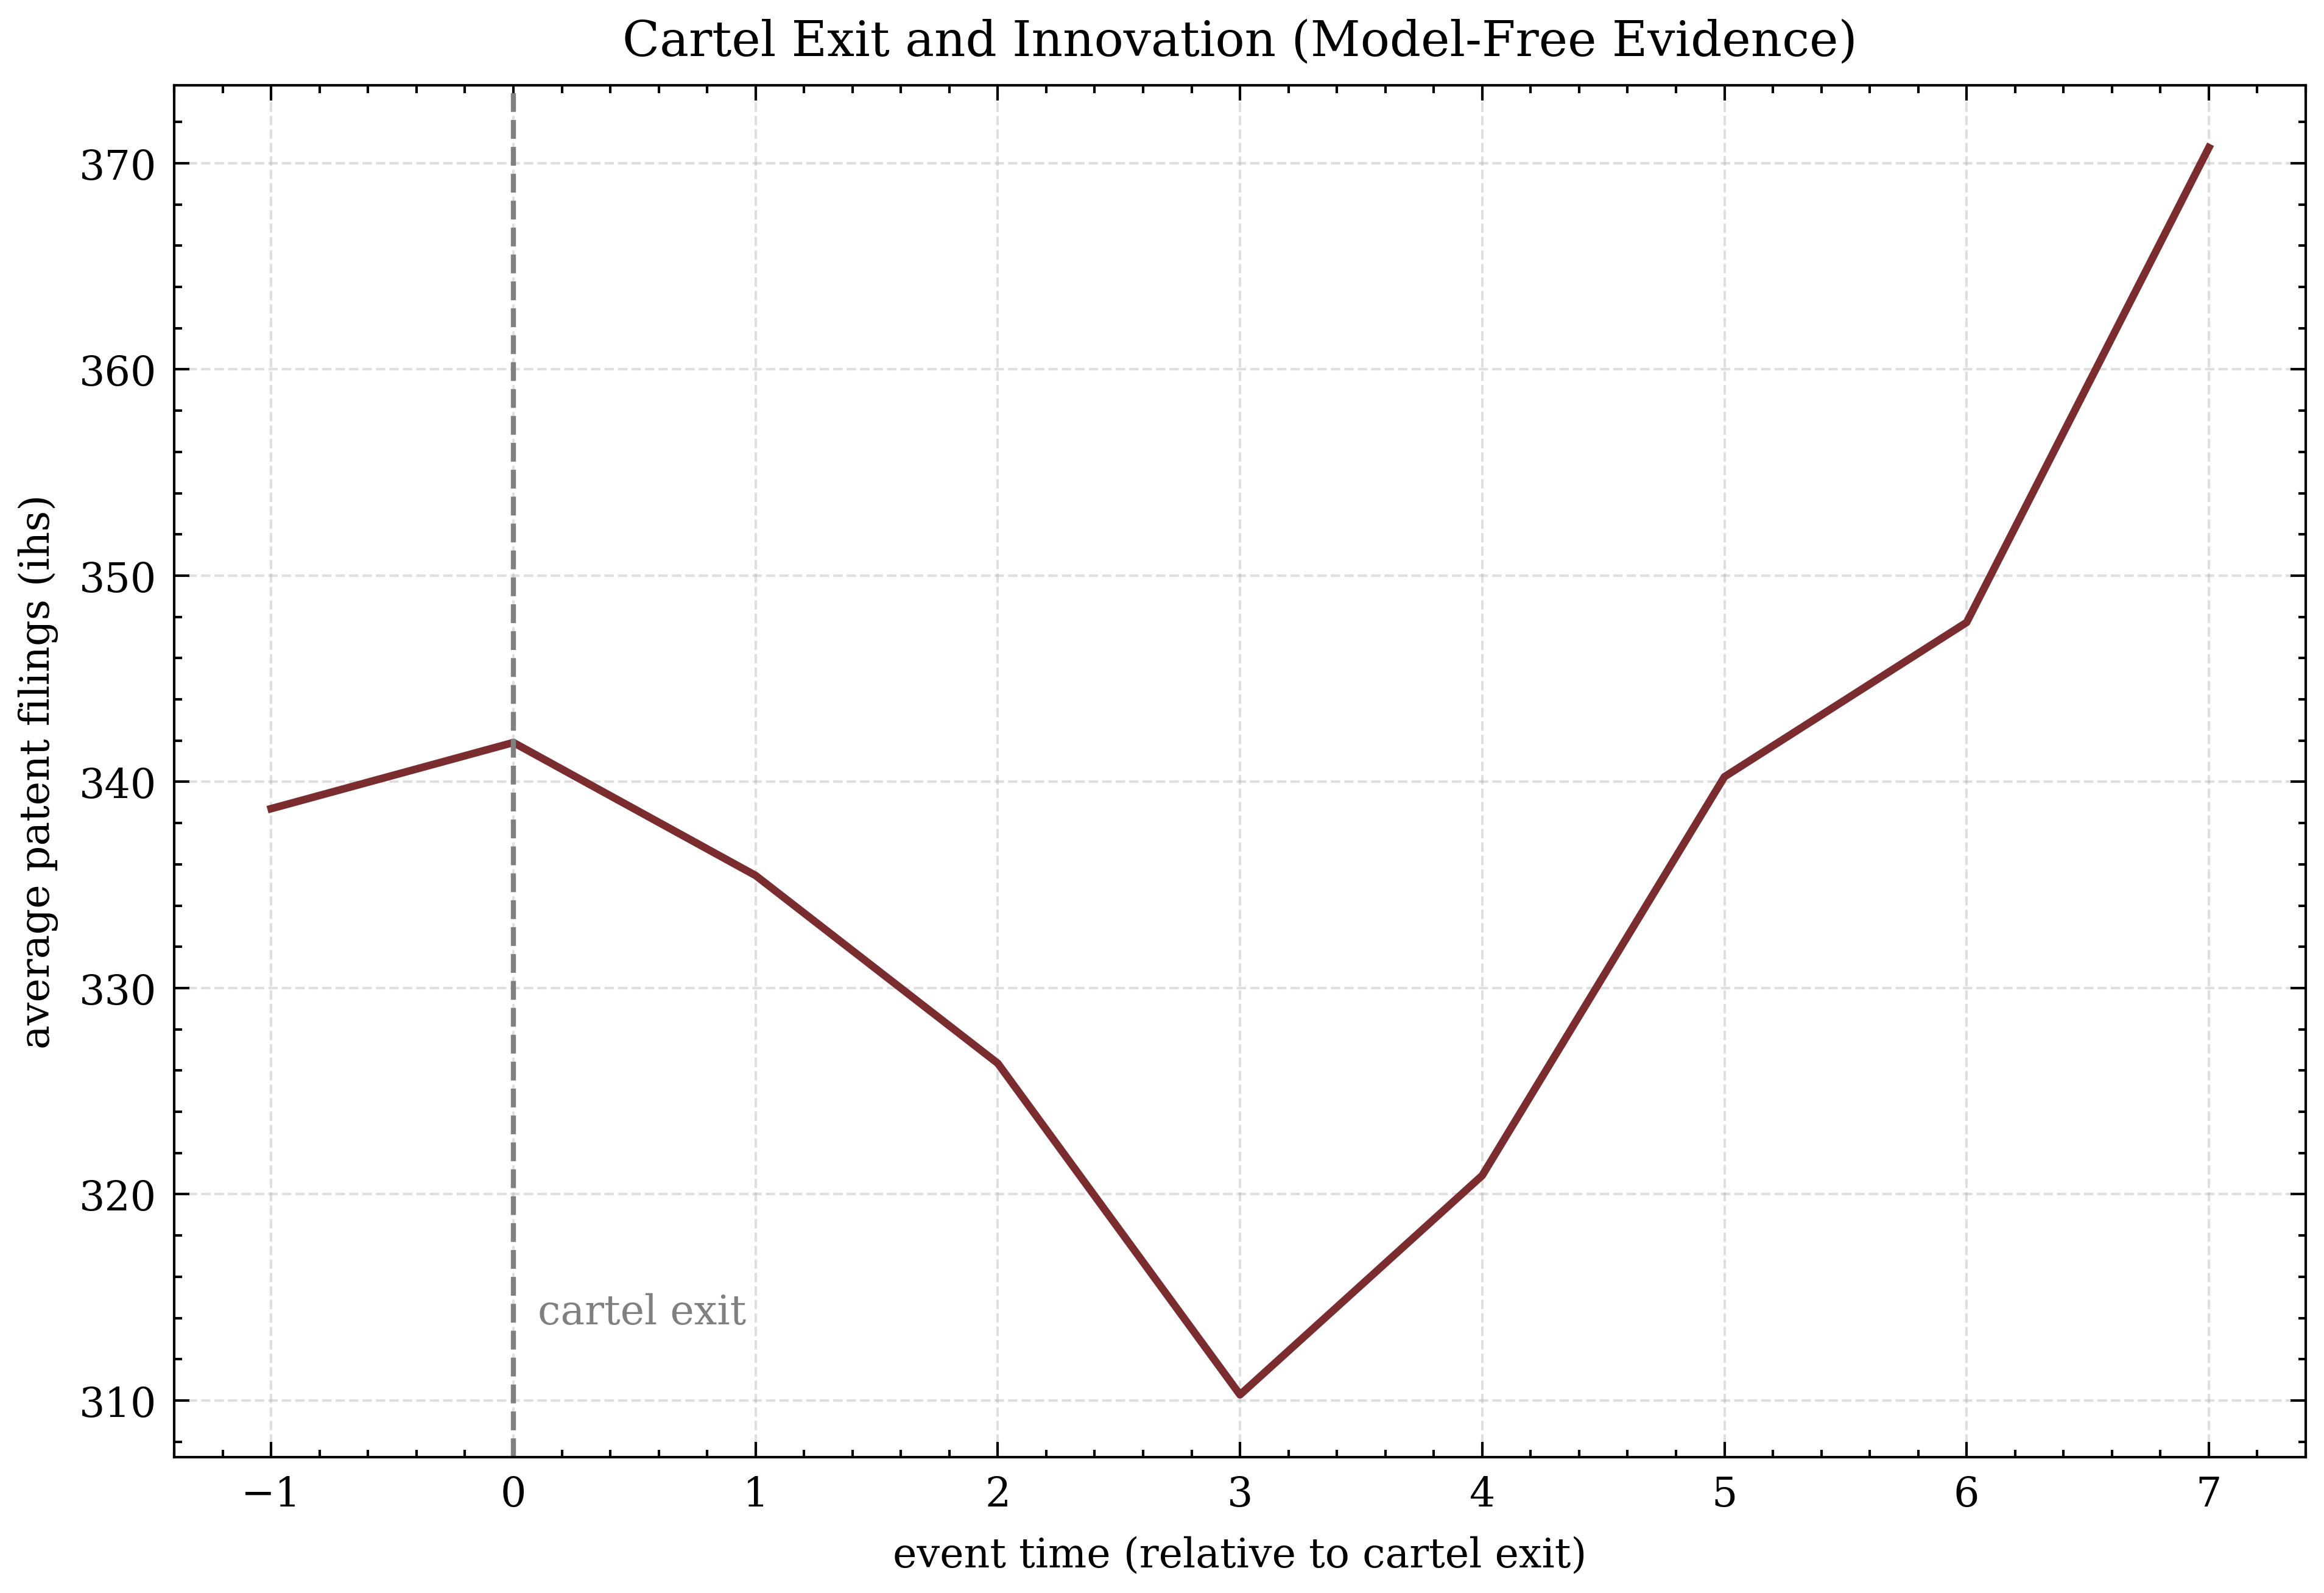

In [132]:
df_event = panel_df[(panel_df['event_time_exit'] >= -2) & (panel_df['event_time_exit'] <= 8)]

df_event_summary = (
    df_event.groupby('event_time_exit')['filed_pat']
    .agg(['mean', 'count', 'std'])
    .reset_index()
)
df_event_summary['smooth_mean'] = df_event_summary['mean'].rolling(window=3, center=True).mean()

plt.style.use(['science', 'ieee'])

# Fix font warnings
plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'DejaVu Serif'
plt.rcParams['mathtext.fontset'] = 'dejavuserif'

# Plot as before
fig, ax = plt.subplots(figsize=(6.5, 4.5))

# Lilac line
ax.plot(df_event_summary['event_time_exit'], df_event_summary['smooth_mean'],
        color='#7B2C2F', linewidth=1.5, label='Average IHS Patents')

# Grey vertical line
ax.axvline(0, color='grey', linestyle='--', linewidth=1)

# Annotation
ax.text(0.1, df_event_summary['smooth_mean'].min() + 0.05*(df_event_summary['smooth_mean'].max() - df_event_summary['smooth_mean'].min()),
        'cartel exit', color='grey', rotation=0,
        verticalalignment='bottom', horizontalalignment='left')

# Labels, title, grid
ax.set_xlabel('event time (relative to cartel exit)')
ax.set_ylabel('average patent filings (ihs)')
ax.set_title('Cartel Exit and Innovation (Model-Free Evidence)')
ax.grid(True, linestyle='--', alpha=0.4)
fig.tight_layout()
plt.show()
